<a href="https://colab.research.google.com/github/IshworC/AI-and-ML/blob/main/worksheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Worksheet 4 - Devanagari Digit Classification


### Name: Sujal Shrestha , ID: 2357917

## Question 1

Load and prepare the Devanagari handwritten digit dataset from Google Drive. This includes mounting Drive, reading images from the `Train` and `Test` folders, converting them to grayscale, resizing them to `28 x 28`, normalizing the pixel values, and checking some sample images.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Using dataset folder: /content/devanagari_data/DevanagariHandwrittenDigitDataset
x_train shape: (17000, 28, 28, 1)
y_train shape: (17000,)
x_test shape: (3000, 28, 28, 1)
y_test shape: (3000,)


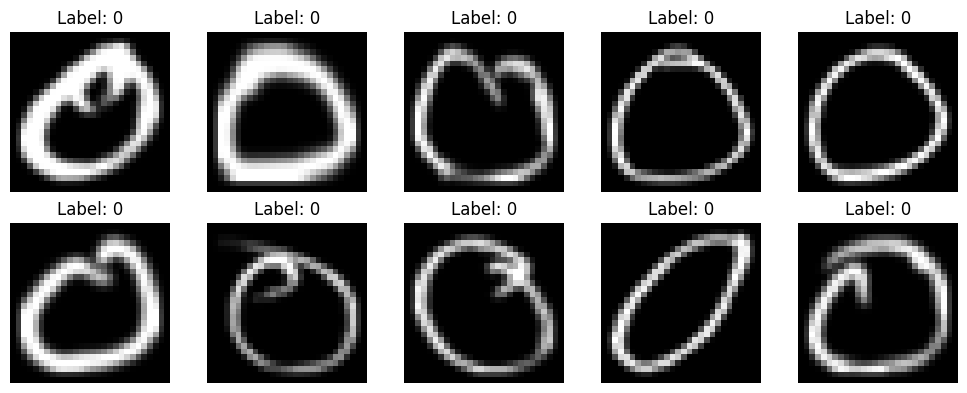

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

zip_path = '/content/drive/MyDrive/Copy of devnagari digit.zip'

# unzipping the file here because it is faster than keeping all folders in Drive
extract_path = '/content/devanagari_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

dataset_root = extract_path

if os.path.exists(os.path.join(extract_path, 'Train')) and os.path.exists(os.path.join(extract_path, 'Test')):
    dataset_root = extract_path
else:
    folders_inside = os.listdir(extract_path)
    for folder_name in folders_inside:
        maybe_path = os.path.join(extract_path, folder_name)
        train_check = os.path.join(maybe_path, 'Train')
        test_check = os.path.join(maybe_path, 'Test')
        if os.path.isdir(train_check) and os.path.isdir(test_check):
            dataset_root = maybe_path
            break

train_path = os.path.join(dataset_root, 'Train')
test_path = os.path.join(dataset_root, 'Test')

print('Using dataset folder:', dataset_root)

img_size = 28

def load_data(folder_path):
    images = []
    labels = []
    class_folders = sorted(os.listdir(folder_path))

    for folder_name in class_folders:
        folder_full_path = os.path.join(folder_path, folder_name)

        if os.path.isdir(folder_full_path):
            label = int(folder_name.split('_')[1])
            files = os.listdir(folder_full_path)

            for file_name in files:
                img_path = os.path.join(folder_full_path, file_name)
                img = Image.open(img_path).convert('L')
                img = img.resize((img_size, img_size))
                img = np.array(img) / 255.0
                images.append(img)
                labels.append(label)

    images = np.array(images)
    labels = np.array(labels)
    return images, labels

x_train, y_train = load_data(train_path)
x_test, y_test = load_data(test_path)

# adding the channel part for keras
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title('Label: ' + str(y_train[i]))
    plt.axis('off')

plt.tight_layout()
plt.show()

## Question 2

Build a fully connected neural network using Keras. The model should have three hidden layers with `64`, `128`, and `256` neurons, all using sigmoid activation, and one output layer with `10` neurons using softmax.

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(64, activation='sigmoid'),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dense(256, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Question 3

Compile the model using a suitable optimizer, loss function, and metric. Since the labels are stored as integers from `0` to `9`, I am using `sparse_categorical_crossentropy`.

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully')

Model compiled successfully


## Question 4

Train the model using `model.fit()`. The worksheet asks for batch size `128`, epochs `20`, and validation split `0.2`. After training, plot the training and validation loss and accuracy.

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5068 - loss: 1.5273 - val_accuracy: 0.0000e+00 - val_loss: 7.2934
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8354 - loss: 0.4786 - val_accuracy: 0.0000e+00 - val_loss: 8.4879
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9202 - loss: 0.2804 - val_accuracy: 0.0000e+00 - val_loss: 9.1431
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9447 - loss: 0.1944 - val_accuracy: 0.0000e+00 - val_loss: 9.4458
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9561 - loss: 0.1497 - val_accuracy: 0.0000e+00 - val_loss: 9.6931
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9651 - loss: 0.1198 - val_accuracy: 0.0000e+00 - val_loss: 10.0586
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9715 - loss: 0.1002 - val_accuracy: 0.0000e+00 - val_loss: 10.0241
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9774 -

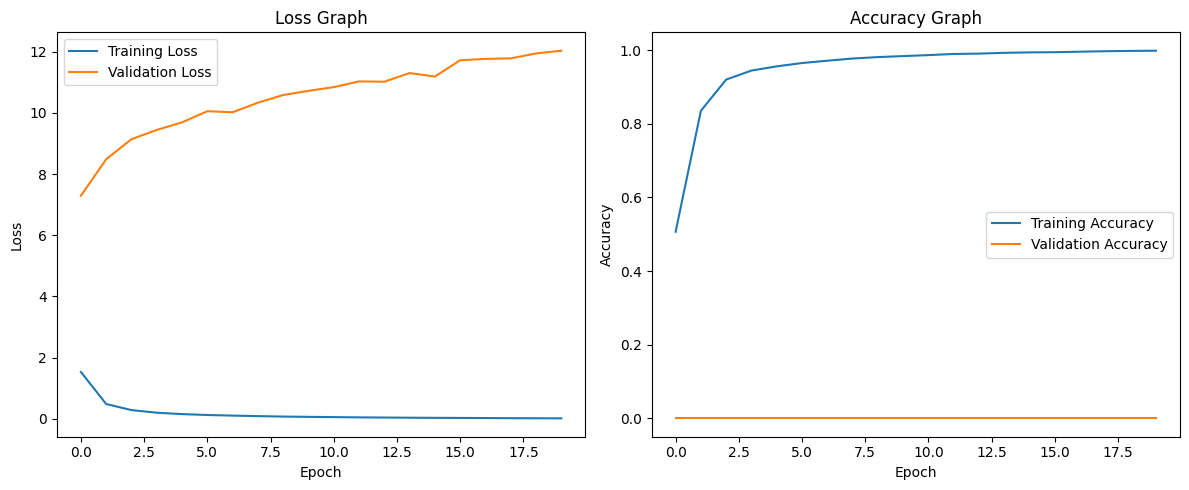

In [ ]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Graph')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Graph')
plt.legend()

plt.tight_layout()
plt.show()

## Question 5

Evaluate the trained model on the test set using `model.evaluate()` and display the test loss and test accuracy.

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print('Test loss:', test_loss)
print('Test accuracy:', test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7830 - loss: 2.4607
Test loss: 2.4607248306274414
Test accuracy: 0.7829999923706055


## Question 6

Save the trained model as an `.h5` file, then load it again and check its performance on the test data.

In [ ]:
model.save('devanagari_fcn_model.h5')
print('Model saved')

loaded_model = tf.keras.models.load_model('devanagari_fcn_model.h5')
print('Model loaded again')

loaded_loss, loaded_accuracy = loaded_model.evaluate(x_test, y_test)

print('Loaded model loss:', loaded_loss)
print('Loaded model accuracy:', loaded_accuracy)

Model saved
Model loaded again
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7830 - loss: 2.4607
Loaded model loss: 2.4607248306274414
Loaded model accuracy: 0.7829999923706055


## Question 7

Use the trained model to make predictions on the test images. Convert the output probabilities into digit labels using `np.argmax()` and compare some predicted labels with the actual labels.

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 0


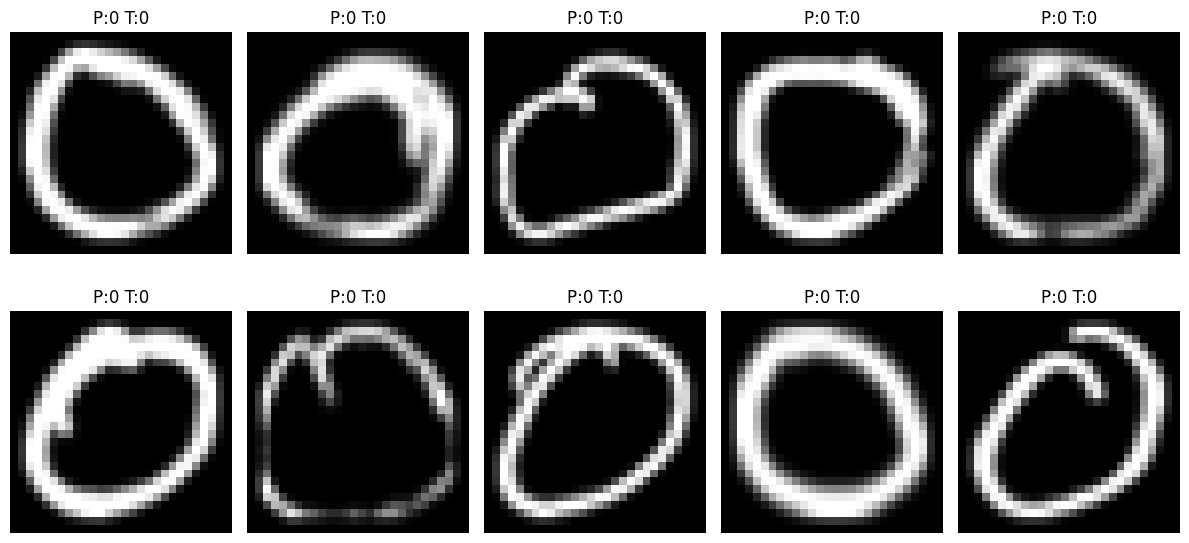

In [ ]:
predictions = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

for i in range(10):
    print('Predicted:', predicted_labels[i], '| Actual:', y_test[i])

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title('P:' + str(predicted_labels[i]) + ' T:' + str(y_test[i]))
    plt.axis('off')

plt.tight_layout()
plt.show()